The model gives a lot of no-responses. 

We want to turn those responses to either 
1) random guess
2) guess with other item

Find model output, see and then change that to random guess.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import random
sns.set()
from decodedoutputdefs import Precision, training_curve_indv, training_curve_average #class with the compiled definitions

In [2]:
class Precision():
    def __init__(self, stim = (0, 360)):
        #stim = (0.4, 3.4)
        #df = pd.read_csv(file,'\s+')
        ##df = pd.read_csv(file)
        #self.df = df
        self.stim = stim
        
    def get_diffs(self,df, nonresponse):
        df_include= []
        for i in df['$TrialName']:
            if 'Recall' in i:
                df_include.append('True')
            else:
                df_include.append('False')
        df.index = df_include
        df_recall = df.loc['True']
        self.df_recall = df_recall
        #pull out target and actual decoded output for recall and all trials
        decodeout = df['#OutDecode']
        target = df['#OutTarget']
        decodeout_recall = df_recall['#OutDecode']
        target_recall = df_recall['#OutTarget']
        
        
        if nonresponse == 'guess':
            use_decodeout = []
            use_decodeout_recall = []
            
            for i in range(len(decodeout)):
                if decodeout.values[i] == 0:
                    use_decodeout.append(np.random.uniform(0,360))
                else:
                    use_decodeout.append(decodeout.values[i])
                    
            for i in range(len(decodeout_recall)):
                if decodeout_recall.values[i] == 0:
                    use_decodeout_recall.append(np.random.uniform(0,360))
                else:
                    use_decodeout_recall.append(decodeout_recall.values[i])
        if nonresponse == 'swap':
            stripes = [i for i in df.keys() if 'stripe' in i] #find the stripe names

            use_decodeout = [] #the new output for all trials
            use_decodeout_recall = [] #the new output for recall 

            for i in range(len(decodeout)):
                if decodeout.values[i] == 0:
                    stripe_value = []
                    for s in stripes: #need the original df
                        if df[s].values[i] != 0:
                            stripe_value.append(df[s].values[i])
                    if len(stripe_value)== 0:
                        use_decodeout.append(np.random.uniform(0,360))
                    else:
                        use_decodeout.append(random.choice(stripe_value))
                else:
                    use_decodeout.append(decodeout.values[i])
            
            for i in range(len(decodeout_recall)):
                if decodeout_recall.values[i] == 0:
                    stripe_value = []
                    for s in stripes: #need the original df
                        if df_recall[s].values[i] != 0:
                            stripe_value.append(df_recall[s].values[i])
                    if len(stripe_value)== 0:
                        use_decodeout_recall.append(np.random.uniform(0,360))
                    else:
                        use_decodeout_recall.append(random.choice(stripe_value)) #random guess from what is in memory. 
                else:
                    use_decodeout_recall.append(decodeout_recall.values[i])
            
        else: 
            use_decodeout = decodeout
            use_decodeout_recall = decodeout_recall
            

        stim_diff = (self.stim[1]-self.stim[0])/2
        diff =np.array(use_decodeout)-np.array(target)
        self.alldiff = diff
        
        diffrecall =np.array(use_decodeout_recall)-np.array(target_recall)
        #diffrecall = np.abs(diffrecall) #this is wrong wrong wrong....uncomment this (comment out the below line) and plot for reason why. 
        #diffrecall = (np.mod(diffrecall+stim_diff/2, stim_diff)-stim_diff/2) #correct version, wrong mod factor
        diffrecall = (np.mod(diffrecall+stim_diff, self.stim[1])-stim_diff)
        #diffrecall = np.mod(diffrecall, stim_diff)  #this is wrong because the errors are from 0 to 360 instead of centered at 0.
        
        #diffrecall = (np.mod(diffrecall+stim_diff/2, stim_diff)-stim_diff/2)/stim_diff*360 #degrees
        self.recalldiff = diffrecall
        return diff,diffrecall
    
    def mult_models(self,files,sep = '\s+', nonresponse = 'none'):
        #this is for plotting error histogram when you have multiple models and want them plotted in one graph 
        #nonresponse is to deal with all the times the model guessing nothing (i.e. it has 0 value)
        #if none - leave as is, if 'guess' then replace with random uniform guess, if 'swap' will replace with the other value
        dat = pd.DataFrame()
        for f in files:
            dat = dat.append(pd.read_csv(f,sep=sep))
        self.dat = dat

        _,diffrecall = self.get_diffs(dat, nonresponse = nonresponse)
        self.diffrecall = diffrecall
        return diffrecall

(array([2103., 2191., 2158., 1989., 5327., 5611., 2010., 2867., 1583.,
        2096.]), array([-1.80000e+02, -1.44009e+02, -1.08018e+02, -7.20270e+01,
        -3.60360e+01, -4.50000e-02,  3.59460e+01,  7.19370e+01,
         1.07928e+02,  1.43919e+02,  1.79910e+02]), <a list of 10 Patch objects>)

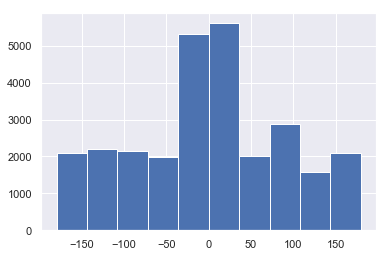

In [66]:
base_nochunk = 'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/'
files = os.listdir(base_nochunk)
files = [f for f in files if '.csv' in f]
full_files = [base_nochunk+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files)
plt.hist(err)

(array([2132., 2126., 2220., 2245., 5303., 5132., 2234., 2244., 2120.,
        2179.]),
 array([-1.80000000e+02, -1.44003780e+02, -1.08007559e+02, -7.20113391e+01,
        -3.60151188e+01, -1.88985308e-02,  3.59773218e+01,  7.19735421e+01,
         1.07969762e+02,  1.43965983e+02,  1.79962203e+02]),
 <a list of 10 Patch objects>)

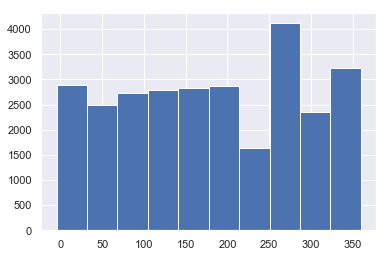

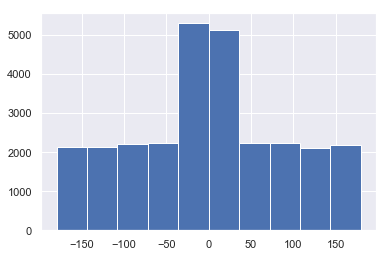

In [78]:
base_nochunk = 'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/'
files = os.listdir(base_nochunk)
files = [f for f in files if '.csv' in f]
full_files = [base_nochunk+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files,nonresponse = 'guess')
plt.hist(p.df_recall['#OutTarget'])
plt.figure()
plt.hist(err)

(array([2073., 2020., 2145., 2105., 5687., 5474., 2174., 2158., 2090.,
        2009.]), array([-1.80000e+02, -1.44009e+02, -1.08018e+02, -7.20270e+01,
        -3.60360e+01, -4.50000e-02,  3.59460e+01,  7.19370e+01,
         1.07928e+02,  1.43919e+02,  1.79910e+02]), <a list of 10 Patch objects>)

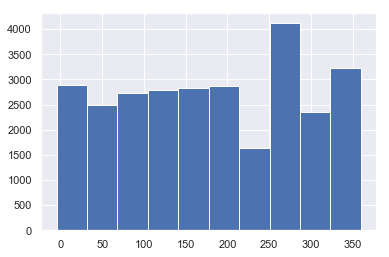

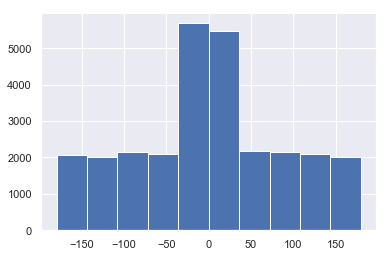

In [110]:
base_nochunk = 'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/'
files = os.listdir(base_nochunk)
files = [f for f in files if '.csv' in f]
full_files = [base_nochunk+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files,nonresponse = 'swap')
plt.hist(p.df_recall['#OutTarget'])
plt.figure()
plt.hist(err)

(array([2050., 2023., 2100., 1814., 5887., 6105., 1849., 2546., 1601.,
        1970.]), array([-1.80000e+02, -1.44005e+02, -1.08010e+02, -7.20150e+01,
        -3.60200e+01, -2.50000e-02,  3.59700e+01,  7.19650e+01,
         1.07960e+02,  1.43955e+02,  1.79950e+02]), <a list of 10 Patch objects>)

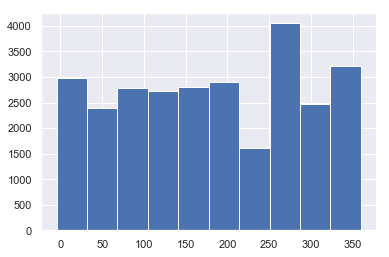

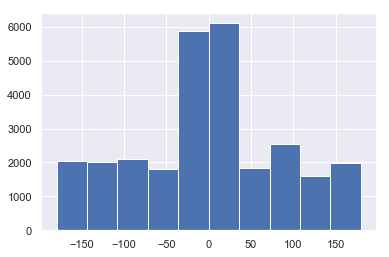

In [77]:
base_chunk = 'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/'
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files)
plt.hist(p.df_recall['#OutTarget'])
plt.figure()
plt.hist(err)

(array([2024., 2027., 2032., 2049., 5849., 5809., 1927., 2101., 2077.,
        2050.]),
 array([-1.80000000e+02, -1.44001755e+02, -1.08003510e+02, -7.20052653e+01,
        -3.60070204e+01, -8.77555702e-03,  3.59894693e+01,  7.19877142e+01,
         1.07985959e+02,  1.43984204e+02,  1.79982449e+02]),
 <a list of 10 Patch objects>)

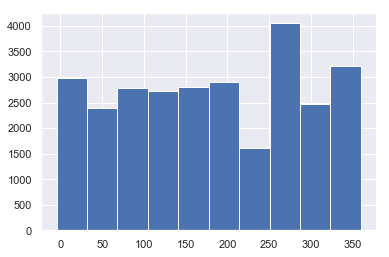

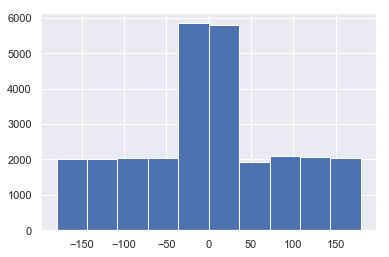

In [76]:
base_chunk = 'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/'
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files, nonresponse = 'guess')
plt.hist(p.df_recall['#OutTarget'])
plt.figure()
plt.hist(err)

(array([1989., 1980., 1982., 1943., 6133., 6086., 1874., 2000., 1967.,
        1991.]), array([-1.80000e+02, -1.44005e+02, -1.08010e+02, -7.20150e+01,
        -3.60200e+01, -2.50000e-02,  3.59700e+01,  7.19650e+01,
         1.07960e+02,  1.43955e+02,  1.79950e+02]), <a list of 10 Patch objects>)

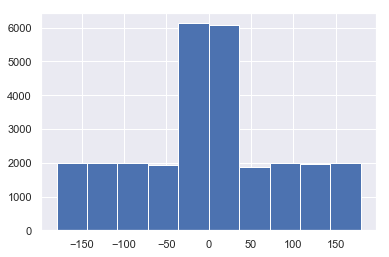

In [111]:
base_chunk = 'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/'
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files, nonresponse = 'swap')
plt.hist(err)

In [ ]:
#seeing if we can do swap errors. 

In [79]:
base_nochunk = 'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/'
file = 'sir4model0_RewThreshold5.5_decoded_Base.csv'

p = Precision()
p.mult_models([base_nochunk+file])
df = p.df_recall

In [88]:
stripes = [i for i in df.keys() if 'stripe' in i]
#this is the way to get all the stripes. 

In [106]:
stripes = [i for i in df.keys() if 'stripe' in i] #find the stripe names
outdecode = df['#OutDecode']
use_outdecode = [] #the new output 

for i in range(len(outdecode)):
    if outdecode.values[i] == 0:
        stripe_value = []
        for s in stripes: #need the original df
            if df[s].values[i] != 0:
                stripe_value.append(df[s].values[i])
        if len(stripe_value)== 0:
            use_outdecode.append(np.random.uniform(0,360))
        else:
            use_outdecode.append(random.choice(stripe_value))
    else:
        use_outdecode.append(outdecode.values[i])

In [112]:
outdecode_recall = df['#OutDecode']
outdecode_target = df['#OutTarget']
stripe = df[stripes[0]]
stripe2 = df[stripes[1]]

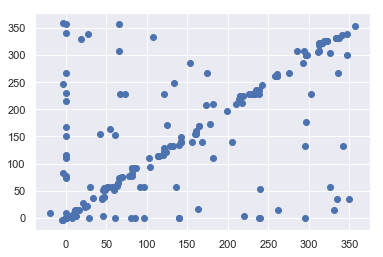

In [114]:
plt.scatter(outdecode_recall,stripe)

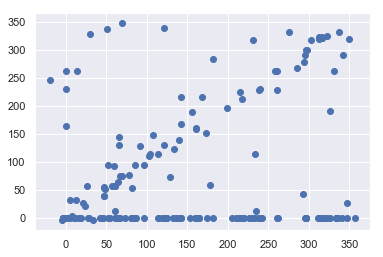

In [115]:
plt.scatter(outdecode_recall,stripe2)

In [118]:
#want to see if when response is 0 - if stripe 1 or stripe 2 has is correlated with out-target
targ_zero = []
stripe_zero = []
stripe2_zero = []
for i in range(len(outdecode_recall)):
    if outdecode_recall.values[i] == 0:
        targ_zero.append(outdecode_target.values[i])
        stripe_zero.append(stripe.values[i])
        stripe2_zero.append(stripe2.values[i])

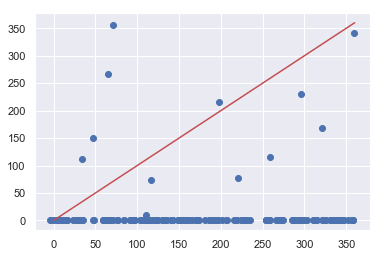

In [125]:
plt.scatter(targ_zero,stripe_zero)
x = np.linspace(0,360,10)
plt.plot(x,x, 'r')

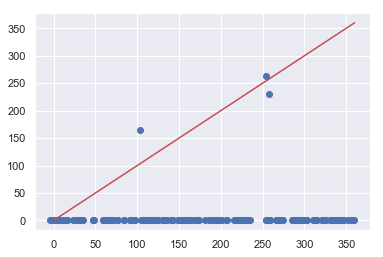

In [126]:
plt.scatter(targ_zero,stripe2_zero)
plt.plot(x,x,'r')